# Калибровка моделей PD: сравнение методов с акцентом на сплайн-калибровку

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from data.generate_data import generate_credit_data, get_oot_split, portfolio_summary
from src.calibrators import get_all_calibrators
from src.metrics import (
    brier_score,
    bootstrap_ci,
    discrimination_metrics,
    fixed_bin_table,
    get_calibration_curve,
    summary_metrics,
)
from src.capital import IRBAssumptions, compare_irb_capital_by_method, calculate_irb_capital

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]
RANDOM_STATE = 42

print("Библиотеки и проектные модули загружены.")

Библиотеки и проектные модули загружены.


## 1. Постановка исследования и критерии сравнения

В рамках **Basel III / IRB-подхода** калибровка PD нужна не только для того, чтобы прогнозные вероятности совпадали с наблюдаемыми дефолтами по бинам риска, но и для того, чтобы итоговая оценка кредитного риска не искажала **резервы, RWA и требуемый капитал**. Поэтому в работе сравниваются не только графики калибровки, но и прикладной эффект от того, как каждый метод перераспределяет PD по шкале риска.

В исследовании сопоставляются шесть вариантов оценки PD на одной и той же базовой модели: **RF без калибровки**, **логит-калибровка**, **изотоническая регрессия**, **бета-калибровка**, **сплайн-калибровка** и **французский сплайн-калибровка**. Под сплайн-калибровкой понимается **монотонный гладкий сплайн**. Под **французским сплайном** понимается двухшаговая схема по мотивам подхода Banque de France / ICAS: сначала исходные PD калибруются логит-моделью, а затем логит-калиброванные PD дополнительно сглаживаются сплайном.

**Цель исследования** — определить, какой способ калибровки даёт наиболее обоснованное распределение PD по всей шкале риска и как это отражается на прикладном результате: величине **Reserves**, **RWA**, **требуемого капитала при H1 = 8%** и **экономии капитала относительно сырых PD**.

**Критерии сравнения** разделены на две группы:
- **статистические**: Brier Score, Log-Loss, ECE, HL p-value, а также визуальная согласованность PD с фактическими дефолтами по reliability-diagram и по фиксированным бинам `[0.0–0.1], …, [0.9–1.0]`;
- **прикладные**: итоговые **Reserves**, **имплицитный RWA**, **требуемый капитал при H1 = 8%**, **экономия капитала относительно сырых PD** и уровень **H1**, если сохранить капитал, достаточный для сырых PD.

Для сопоставимости прикладной части принимаются фиксированные допущения: **EAD = 1 000 000** для каждого наблюдения и **LGD = 40%**. Поэтому различия в итоговом капитале интерпретируются как эффект именно от выбора метода калибровки PD.

## 2. Данные: синтетический кредитный портфель

In [2]:
df = generate_credit_data(n_samples=40000, random_state=RANDOM_STATE)

print(f"Датасет: {df.shape[0]:,} строк | {df.shape[1]} столбцов")
print(f"Общая доля дефолтов: {df['default'].mean():.2%}")
print(f"Средняя истинная PD в синтетике: {df['true_pd'].mean():.2%}\n")

true_pd_stats = df["true_pd"].describe(percentiles=[0.50, 0.90, 0.95, 0.99])[["min", "50%", "90%", "95%", "99%", "max"]]
print("Распределение истинной PD в портфеле:")
print(true_pd_stats.map(lambda x: f"{x:.2%}"))

segment_stats = (
    df.groupby("risk_segment")
      .agg(наблюдений=("default", "count"), доля_дефолтов=("default", "mean"), средняя_true_pd=("true_pd", "mean"))
)
segment_map = {0: "0 = prime", 1: "1 = standard", 2: "2 = subprime", 3: "3 = distressed"}
segment_stats.index = segment_stats.index.map(segment_map)
segment_stats["доля_дефолтов"] = segment_stats["доля_дефолтов"].map("{:.2%}".format)
segment_stats["средняя_true_pd"] = segment_stats["средняя_true_pd"].map("{:.2%}".format)
print("\nРиск-сегменты синтетического портфеля:")
print(segment_stats)

by_year = df.groupby("origination_year")["default"].agg(всего="count", дефолтов="sum", доля="mean")
by_year["доля"] = by_year["доля"].map("{:.2%}".format)
print("\nДефолты по годам выдачи:")
print(by_year)

display(df.drop(columns=["default", "origination_year", "risk_segment", "true_pd"]).describe().round(2))

Датасет: 40,000 строк | 12 столбцов
Общая доля дефолтов: 13.66%
Средняя истинная PD в синтетике: 13.62%

Распределение истинной PD в портфеле:
min     0.23%
50%     1.76%
90%    51.22%
95%    82.49%
99%    95.24%
max    99.58%
Name: true_pd, dtype: str

Риск-сегменты синтетического портфеля:
                наблюдений доля_дефолтов средняя_true_pd
risk_segment                                            
0 = prime            15119         0.69%           0.63%
1 = standard         13601         2.54%           2.60%
2 = subprime          8082        28.97%          29.06%
3 = distressed        3198        83.52%          82.86%

Дефолты по годам выдачи:
                  всего  дефолтов    доля
origination_year                         
2019               5513       739  13.40%
2020               5576       839  15.05%
2021               7219       983  13.62%
2022               7275       964  13.25%
2023               8045      1021  12.69%
2024               6372       916  14.38%


,credit_score,ltv,dti,employment_years,loan_amount,loan_term,num_delinquencies,loan_purpose
count,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00
mean,654.48,0.42,0.30,6.38,221.19,45.94,0.51,1.00
std,117.18,0.23,0.20,4.25,229.40,24.13,0.90,0.88
min,300.00,0.05,0.03,0.00,14.80,12.00,0.00,0.00
25%,578.00,0.23,0.13,3.00,103.78,24.00,0.00,0.00
50%,677.00,0.38,0.24,6.00,156.30,48.00,0.00,1.00
75%,747.00,0.61,0.43,9.30,256.40,60.00,1.00,2.00
max,850.00,0.95,0.87,23.90,9119.70,120.00,8.00,2.00


### Проверка сценариев портфеля: normal vs stress

В проекте есть два режима генерации портфеля. Основной notebook дальше использует `stress`, потому что в нем хорошо заселена верхняя часть PD-шкалы и легче увидеть эффект калибровки на RWA. Но для банковской интерпретации полезно отдельно видеть, что `normal` портфель существует и дает более умеренную дефолтность.

In [3]:
scenario_rows = []
for scenario in ["normal", "stress"]:
    scenario_df = generate_credit_data(n_samples=40_000, random_state=RANDOM_STATE, portfolio=scenario)
    summary = portfolio_summary(scenario_df)
    scenario_rows.append({
        "scenario": scenario,
        "n_obs": summary["n_obs"],
        "default_rate": summary["default_rate"],
        "avg_true_pd": summary["avg_true_pd"],
        "p95_true_pd": summary["p95_true_pd"],
        "max_true_pd": summary["max_true_pd"],
    })

scenario_table = pd.DataFrame(scenario_rows).set_index("scenario")
display(
    scenario_table.style.format({
        "default_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
        "p95_true_pd": "{:.2%}",
        "max_true_pd": "{:.2%}",
    })
)

print("Дальше в notebook используется stress-сценарий, чтобы проверять калибровку не только в низких PD.")

,n_obs,default_rate,avg_true_pd,p95_true_pd,max_true_pd
scenario,,,,,
normal,40000,4.06%,4.07%,21.39%,97.31%
stress,40000,13.66%,13.62%,82.49%,99.58%


Дальше в notebook используется stress-сценарий, чтобы проверять калибровку не только в низких PD.


## 3. Экспериментальный протокол и схема выборок

В эксперименте используется **out-of-time схема**, близкая к банковской практике валидации:
- **Train (2019–2021)** — обучение базовой модели;
- **Calibration (2022–2023)** — обучение калибраторов только на сырых score базовой модели;
- **Test OOT (2024)** — финальная оценка качества калибровки и капитального эффекта на будущих данных.

Базовая модель оценивается один раз на train-периоде. Затем её score на calibration-выборке подаются на вход каждому калибратору. Откалиброванные PD применяются только к OOT-выборке 2024 года.

Важно, что **test OOT не используется для настройки параметров калибраторов**. Для финальной сплайн-калибровки используется только монотонный гладкий вариант без подбора по тестовой выборке, чтобы избежать утечки информации из test в модельный выбор.

In [4]:
X_train, X_calib, X_test, y_train, y_calib, y_test = get_oot_split(df)

print("Out-of-Time разбивка:")
print(f"  Train       (2019-2021): {len(X_train):,} строк | дефолты: {y_train.mean():.2%}")
print(f"  Calibration (2022-2023): {len(X_calib):,} строк | дефолты: {y_calib.mean():.2%}")
print(f"  Test OOT    (2024):      {len(X_test):,} строк  | дефолты: {y_test.mean():.2%}")

Out-of-Time разбивка:
  Train       (2019-2021): 18,308 строк | дефолты: 13.99%
  Calibration (2022-2023): 15,320 строк | дефолты: 12.96%
  Test OOT    (2024):      6,372 строк  | дефолты: 14.38%


## 4. Базовая модель и исходное качество некалиброванных PD

In [5]:
base_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
base_model.fit(X_train, y_train)

scores_calib = np.clip(base_model.predict_proba(X_calib)[:, 1], 1e-6, 1 - 1e-6)
scores_test  = np.clip(base_model.predict_proba(X_test)[:, 1], 1e-6, 1 - 1e-6)

print(f"Диапазон скоров RF на OOT: [{scores_test.min():.4f}, {scores_test.max():.4f}]")
print(f"Медиана скоров RF:         {np.median(scores_test):.4f}")
print(f"90 / 95 / 99 перцентили:   {np.quantile(scores_test, [0.90, 0.95, 0.99]).round(4)}")
print(f"Скоры > 0.5:               {(scores_test > 0.5).mean():.1%}")

Диапазон скоров RF на OOT: [0.0068, 0.9660]
Медиана скоров RF:         0.0217
90 / 95 / 99 перцентили:   [0.4997 0.7505 0.9092]
Скоры > 0.5:               10.0%


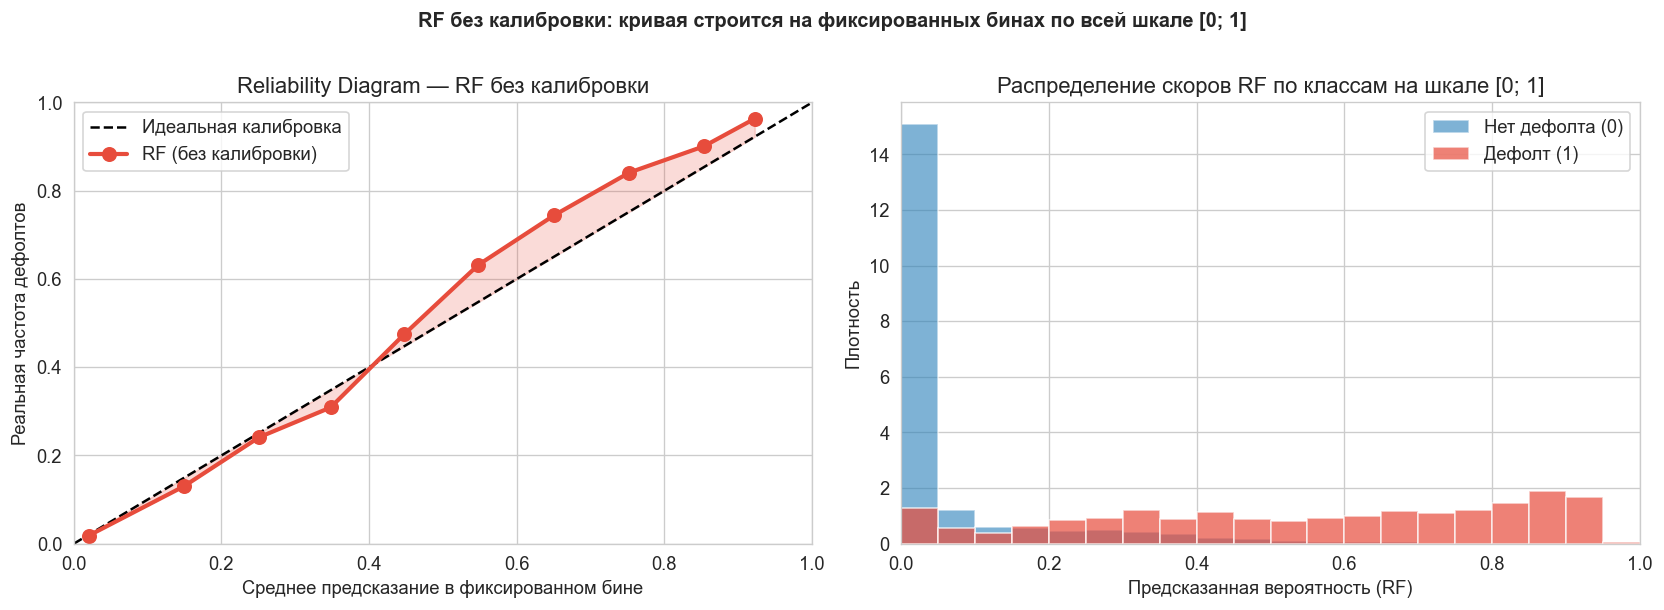

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
mean_pred, frac_pos = get_calibration_curve(y_test.values, scores_test, n_bins=10, strategy="uniform")
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Идеальная калибровка")
ax.plot(mean_pred, frac_pos, "o-", color=COLORS[0], lw=2.5, ms=8, label="RF (без калибровки)")
ax.fill_between(mean_pred, mean_pred, frac_pos, alpha=0.2, color=COLORS[0])
ax.set_xlabel("Среднее предсказание в фиксированном бине")
ax.set_ylabel("Реальная частота дефолтов")
ax.set_title("Reliability Diagram — RF без калибровки")
ax.legend()

x_max = max(scores_test.max() * 1.1, 0.35)
y_max = max(frac_pos.max() * 1.15, 0.35)
ax.set_xlim(0, min(x_max, 1.0))
ax.set_ylim(0, min(y_max, 1.0))

ax = axes[1]
ax.hist(scores_test[y_test == 0], bins=np.linspace(0, 1, 21), alpha=0.6, label="Нет дефолта (0)", color=COLORS[1], density=True)
ax.hist(scores_test[y_test == 1], bins=np.linspace(0, 1, 21), alpha=0.7, label="Дефолт (1)", color=COLORS[0], density=True)
ax.set_xlim(0, 1)
ax.set_xlabel("Предсказанная вероятность (RF)")
ax.set_ylabel("Плотность")
ax.set_title("Распределение скоров RF по классам на шкале [0; 1]")
ax.legend()

plt.suptitle(
    "RF без калибровки: кривая строится на фиксированных бинах по всей шкале [0; 1]",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()


### Почему RF без калибровки может быть неидеальной

Хорошее ранжирование не означает хорошую вероятность дефолта. Random Forest может хорошо отделять дефолтных заемщиков от недефолтных, но его сырые `predict_proba` часто требуют посткалибровки:

- **AUC/Gini/KS** отвечают за порядок заемщиков по риску.
- **Brier, Log-Loss, ECE, calibration slope/intercept** отвечают за качество численных PD.
- Если `slope` заметно отличается от 1, модель неверно масштабирует риск.
- Если `intercept` заметно отличается от 0, модель систематически завышает или занижает уровень PD.

Большой пик недефолтных клиентов в низких PD — это нормально: в кредитном портфеле большинство заемщиков не дефолтит, а хорошая модель должна концентрировать таких клиентов в левой части шкалы.

## 5. Сравнение методов калибровки

В итоговом сравнении оставлена **одна базовая сплайн-модель** — **сплайн-калибровка с монотонным ограничением**.  
Причина: для PD-калибровки монотонность является содержательно предпочтительной, поскольку более высокий исходный риск не должен переводиться в более низкую итоговую PD.

Дополнительно вводится **французский сплайн-калибровка** — двухшаговый метод, в котором:
1. исходные PD сначала калибруются **логит-моделью**;
2. затем полученные логит-калиброванные PD дополнительно сглаживаются **монотонным сплайном**.

Таким образом, в ноутбуке сопоставляются простые параметрические, непараметрические и гибридные методы калибровки PD.

In [7]:
calibrators = get_all_calibrators()
calibrated_probs = {}

for name, cal in calibrators.items():
    cal.fit(scores_calib, y_calib.values)
    calibrated_probs[name] = np.clip(cal.predict(scores_test), 1e-6, 1 - 1e-6)
    print(f"{name}: обучен.")

print("\nВсе калибраторы обучены только на calibration-выборке.")

Логит-калибровка: обучен.
Изотоническая регрессия: обучен.
Бета-калибровка: обучен.
Монотонный сплайн: обучен.
Французский сплайн: обучен.

Все калибраторы обучены только на calibration-выборке.


### Функции калибровки: как raw score превращается в PD

Калибратор можно рассматривать как функцию:

\[
\hat{p}_{calibrated} = f(\hat{p}_{raw})
\]

Если функция лежит выше диагонали, метод повышает исходную PD. Если ниже — снижает. Для банковской интерпретации это важно: два метода могут иметь близкий Brier Score, но по-разному менять хвост распределения PD и, следовательно, RWA.

In [8]:
calibration_function_table = pd.DataFrame([
    {
        "Метод": "RF без калибровки",
        "Функция": "f(s) = s",
        "Интерпретация": "Сырые вероятности базовой модели без постобработки.",
    },
    {
        "Метод": "Логит-калибровка",
        "Функция": "f(s) = sigmoid(a * logit(s) + b)",
        "Интерпретация": "Стабильная параметрическая коррекция уровня и масштаба PD.",
    },
    {
        "Метод": "Изотоническая регрессия",
        "Функция": "f(s) = монотонная ступенчатая функция",
        "Интерпретация": "Гибкая калибровка без заданной формы, но возможны ступени и ties.",
    },
    {
        "Метод": "Бета-калибровка",
        "Функция": "f(s) = sigmoid(a log(s) + b log(1-s) + c)",
        "Интерпретация": "Параметрическая коррекция, хорошо подходит для skewed probability scores.",
    },
    {
        "Метод": "Монотонный сплайн",
        "Функция": "f(s) = PCHIP(isotonic(binned default rates))",
        "Интерпретация": "Гладкая монотонная PD-кривая на основе бинов калибровочной выборки.",
    },
    {
        "Метод": "Французский сплайн",
        "Функция": "f(s) = spline(logit_calibrator(s))",
        "Интерпретация": "Двухшаговая схема: стабильный логит + гладкая монотонная коррекция.",
    },
])

display(calibration_function_table)

,Метод,Функция,Интерпретация
0,RF без калибровки,f(s) = s,Сырые вероятности базовой модели без постобраб...
1,Логит-калибровка,f(s) = sigmoid(a * logit(s) + b),Стабильная параметрическая коррекция уровня и ...
2,Изотоническая регрессия,f(s) = монотонная ступенчатая функция,"Гибкая калибровка без заданной формы, но возмо..."
3,Бета-калибровка,f(s) = sigmoid(a log(s) + b log(1-s) + c),"Параметрическая коррекция, хорошо подходит для..."
4,Монотонный сплайн,f(s) = PCHIP(isotonic(binned default rates)),Гладкая монотонная PD-кривая на основе бинов к...
5,Французский сплайн,f(s) = spline(logit_calibrator(s)),Двухшаговая схема: стабильный логит + гладкая ...


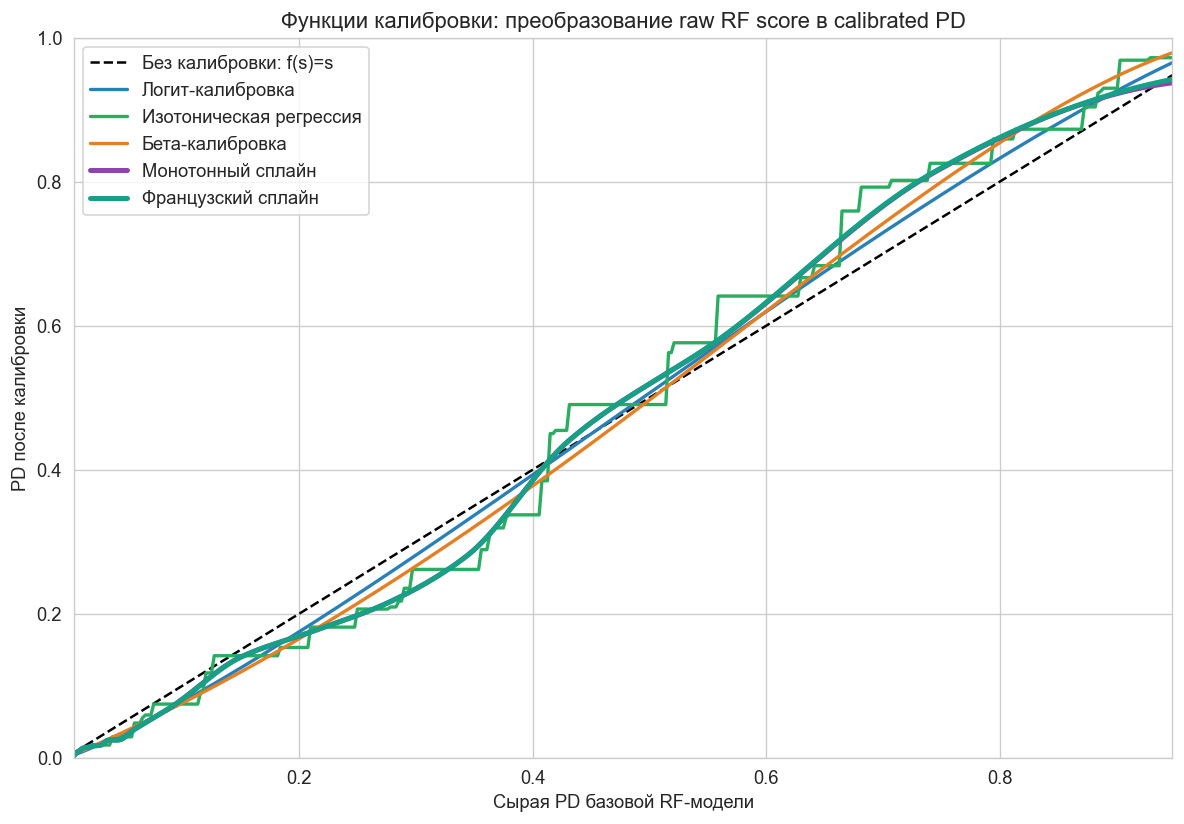

Диапазон графика ограничен 0.1% и 99.9% перцентилями calibration-скоров, чтобы редкие экстремумы не сжимали основную область.


In [9]:
score_grid = np.linspace(
    max(1e-4, float(np.quantile(scores_calib, 0.001))),
    min(0.9999, float(np.quantile(scores_calib, 0.999))),
    400,
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(score_grid, score_grid, "k--", lw=1.5, label="Без калибровки: f(s)=s")

for (name, cal), color in zip(calibrators.items(), COLORS[1:]):
    calibrated_grid = cal.predict(score_grid)
    lw = 3.0 if "сплайн" in name.lower() else 2.0
    ax.plot(score_grid, calibrated_grid, color=color, lw=lw, label=name)

ax.set_xlabel("Сырая PD базовой RF-модели")
ax.set_ylabel("PD после калибровки")
ax.set_title("Функции калибровки: преобразование raw RF score в calibrated PD")
ax.set_xlim(score_grid.min(), score_grid.max())
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("Диапазон графика ограничен 0.1% и 99.9% перцентилями calibration-скоров, чтобы редкие экстремумы не сжимали основную область.")

In [10]:
parameter_rows = []
for name, cal in calibrators.items():
    row = {"Метод": name}

    if hasattr(cal, "_model") and hasattr(cal._model, "coef_"):
        row["Параметры"] = (
            f"a={float(cal._model.coef_[0][0]):.4f}, "
            f"b={float(cal._model.intercept_[0]):.4f}"
        )
    elif hasattr(cal, "a_"):
        row["Параметры"] = (
            f"a={cal.a_:.4f}, b={cal.b_:.4f}, c={cal.c_:.4f}, "
            f"success={cal.success_}"
        )
    elif hasattr(cal, "bin_stats_") and cal.bin_stats_ is not None:
        row["Параметры"] = f"число бинов={len(cal.bin_stats_)}"
    elif hasattr(cal, "spline_stage"):
        row["Параметры"] = f"logit + spline, число бинов={len(cal.spline_stage.bin_stats_)}"
    else:
        row["Параметры"] = "непараметрический метод"

    parameter_rows.append(row)

display(pd.DataFrame(parameter_rows).set_index("Метод"))

,Параметры
Метод,
Логит-калибровка,"a=1.1379, b=0.0265"
Изотоническая регрессия,непараметрический метод
Бета-калибровка,"a=1.0278, b=-1.4151, c=-0.2811, success=True"
Монотонный сплайн,число бинов=30
Французский сплайн,"logit + spline, число бинов=30"


## 6. Результаты на OOT: метрики и визуальная диагностика

**Важно для интерпретации графиков.**  
Кривые калибровки в этой версии строятся на **фиксированных бинах по всей шкале [0; 1]**.  
Это исправляет прежнюю проблему, когда при квантильной разбивке последняя точка на оси X показывала лишь **среднее значение верхнего дециля**, поэтому визуально казалось, что все методы обрываются около `0.15`, хотя фактические максимумы PD были выше.

In [11]:
results = [summary_metrics(y_test.values, scores_test, name="RF без калибровки")]
for name, probs in calibrated_probs.items():
    results.append(summary_metrics(y_test.values, probs, name=name))

df_results = pd.DataFrame(results).set_index("method")

print("Метрики на OOT-выборке, 2024 год:")
print("  Brier Score, Log-Loss, ECE  — чем меньше, тем лучше")
print("  HL p-value                  — чем больше, тем лучше, но при большом n тест часто слишком строгий")
print("  Slope ~ 1, Intercept ~ 0    — ближе к идеальной калибровке")

df_results_ru = df_results.rename(columns={
    "brier_score": "Brier Score",
    "log_loss": "Log-Loss",
    "ece_uniform": "ECE (фикс. бины)",
    "ece_quantile": "ECE (квант. бины)",
    "hl_chi2": "HL chi2",
    "hl_p_value": "HL p-value",
    "cal_slope": "Cal. slope",
    "cal_intercept": "Cal. intercept",
})

display(
    df_results_ru.round({
        "Brier Score": 5,
        "Log-Loss": 5,
        "ECE (фикс. бины)": 5,
        "ECE (квант. бины)": 5,
        "HL chi2": 3,
        "HL p-value": 4,
        "Cal. slope": 4,
        "Cal. intercept": 4,
    })
)

disc_rows = []
all_preds = {"RF без калибровки": scores_test, **calibrated_probs}
for name, probs in all_preds.items():
    disc_rows.append(discrimination_metrics(y_test.values, probs, name=name))

df_disc = pd.DataFrame(disc_rows).set_index("method")
print("\nМетрики ранжирования (AUC / Gini / KS):")
print(df_disc.to_string())
print("\nКомментарий: строго монотонные преобразования обычно сохраняют ранжирование;")
print("изотоническая и сплайн-калибровка могут немного менять AUC/Gini из-за ties или сглаживания.")

prob_range_rows = []
for name, probs in all_preds.items():
    prob_range_rows.append({
        "method": name,
        "min_pd": np.min(probs),
        "p95_pd": np.quantile(probs, 0.95),
        "max_pd": np.max(probs),
    })

df_prob_ranges = pd.DataFrame(prob_range_rows).set_index("method")
df_prob_ranges_ru = df_prob_ranges.rename(columns={
    "min_pd": "Мин. PD",
    "p95_pd": "95-й перцентиль PD",
    "max_pd": "Макс. PD",
})
print("\nФактический диапазон PD на OOT:")
display(df_prob_ranges_ru.round(4))

Метрики на OOT-выборке, 2024 год:
  Brier Score, Log-Loss, ECE  — чем меньше, тем лучше
  HL p-value                  — чем больше, тем лучше, но при большом n тест часто слишком строгий
  Slope ~ 1, Intercept ~ 0    — ближе к идеальной калибровке


,Brier Score,Log-Loss,ECE (фикс. бины),ECE (квант. бины),HL chi2,HL p-value,Cal. slope,Cal. intercept
method,,,,,,,,
RF без калибровки,0.06134,0.20908,0.01279,0.01258,23.875,0.0024,1.1082,0.1525
Логит-калибровка,0.06105,0.20884,0.01152,0.00963,29.075,0.0003,0.9733,0.1247
Изотоническая регрессия,0.06094,0.20955,0.00994,0.01015,24.542,0.0019,0.9610,0.1188
Бета-калибровка,0.06103,0.20837,0.01236,0.00938,19.364,0.0130,0.9785,0.1309
Монотонный сплайн,0.06102,0.20865,0.01104,0.01049,19.305,0.0133,0.9791,0.1395
Французский сплайн,0.06101,0.20862,0.01097,0.01043,19.187,0.0139,0.9778,0.1372



Метрики ранжирования (AUC / Gini / KS):
                         auc_roc    gini  ks_stat
method                                           
RF без калибровки         0.9316  0.8633   0.7380
Логит-калибровка          0.9316  0.8633   0.7380
Изотоническая регрессия   0.9313  0.8625   0.7317
Бета-калибровка           0.9316  0.8633   0.7380
Монотонный сплайн         0.9315  0.8630   0.7380
Французский сплайн        0.9315  0.8630   0.7380

Комментарий: строго монотонные преобразования обычно сохраняют ранжирование;
изотоническая и сплайн-калибровка могут немного менять AUC/Gini из-за ties или сглаживания.

Фактический диапазон PD на OOT:


,Мин. PD,95-й перцентиль PD,Макс. PD
method,,,
RF без калибровки,0.0068,0.7505,0.9660
Логит-калибровка,0.0035,0.7823,0.9788
Изотоническая регрессия,0.0000,0.8256,1.0000
Бета-калибровка,0.0045,0.8003,0.9887
Монотонный сплайн,0.0026,0.8188,0.9401
Французский сплайн,0.0026,0.8197,0.9476


### Как выбирать метод калибровки

Один метод редко является лучшим по всем критериям одновременно. Поэтому ниже метод выбирается не только по статистической метрике, но и по практической роли в банковской модели.

In [12]:
selection_table = pd.DataFrame([
    {
        "Сценарий выбора": "Минимизировать Brier / Log-Loss",
        "Что смотреть": "Brier Score, Log-Loss",
        "Типичный кандидат": df_results["brier_score"].idxmin(),
        "Комментарий": "Лучше для чистого качества вероятностного прогноза.",
    },
    {
        "Сценарий выбора": "Минимизировать ошибку калибровки",
        "Что смотреть": "ECE на квантильных и фиксированных бинах",
        "Типичный кандидат": df_results["ece_quantile"].idxmin(),
        "Комментарий": "Полезно для reliability diagrams и backtesting PD.",
    },
    {
        "Сценарий выбора": "Сохранить простоту и интерпретируемость",
        "Что смотреть": "Стабильность, slope/intercept, governance",
        "Типичный кандидат": "Логит-калибровка / Бета-калибровка",
        "Комментарий": "Хорошие базовые benchmark-методы.",
    },
    {
        "Сценарий выбора": "Получить гладкую PD-кривую",
        "Что смотреть": "ECE, графики, отсутствие ступеней",
        "Типичный кандидат": "Монотонный сплайн / Французский сплайн",
        "Комментарий": "Удобно для банковской master scale и презентации калибровочной функции.",
    },
    {
        "Сценарий выбора": "Оценить capital impact",
        "Что смотреть": "RWA, required capital, H1 if keep raw capital",
        "Типичный кандидат": "Определяется отдельно в RWA-блоке",
        "Комментарий": "Лучший по Brier метод не обязан давать минимальный капитал.",
    },
])

display(selection_table)

,Сценарий выбора,Что смотреть,Типичный кандидат,Комментарий
0,Минимизировать Brier / Log-Loss,"Brier Score, Log-Loss",Изотоническая регрессия,Лучше для чистого качества вероятностного прог...
1,Минимизировать ошибку калибровки,ECE на квантильных и фиксированных бинах,Бета-калибровка,Полезно для reliability diagrams и backtesting...
2,Сохранить простоту и интерпретируемость,"Стабильность, slope/intercept, governance",Логит-калибровка / Бета-калибровка,Хорошие базовые benchmark-методы.
3,Получить гладкую PD-кривую,"ECE, графики, отсутствие ступеней",Монотонный сплайн / Французский сплайн,Удобно для банковской master scale и презентац...
4,Оценить capital impact,"RWA, required capital, H1 if keep raw capital",Определяется отдельно в RWA-блоке,Лучший по Brier метод не обязан давать минимал...


### Эффект калибровки на резервы, RWA и требуемый капитал

После статистического сравнения каждая версия PD переводится в прикладные показатели: **Reserves**, **имплицитный RWA**, **требуемый капитал при H1 = 8%** и **Capital_true**. Это позволяет оценить не только качество калибровки как статистической процедуры, но и её влияние на капитальную нагрузку портфеля.

Для чистоты сравнения используется фиксированное допущение **EAD = 1 000 000** на каждое наблюдение и **LGD = 40%**. Поэтому различия между методами интерпретируются как эффект именно от калиброванной **PD**, а не от разного размера экспозиции.

Дополнительно рассчитывается, сколько капитала можно высвободить относительно **сырых PD** при целевом нормативе **H1 = 8%**, а также каким станет фактический **H1**, если сохранить капитал, достаточный для некалиброванной базовой модели.

In [13]:
pred_map = {"RF без калибровки": scores_test, **calibrated_probs}

capital_assumptions = IRBAssumptions(
    lgd=0.40,
    maturity_years=2.5,
    ead=1_000_000.0,
)

df_rwa = compare_irb_capital_by_method(
    pred_map,
    assumptions=capital_assumptions,
    baseline_method="RF без калибровки",
)

base_required_capital = df_rwa.loc["RF без калибровки", "total_required_capital"]
df_rwa["h1_if_keep_raw_capital"] = base_required_capital / df_rwa["total_rwa"]
df_rwa["h1_uplift_vs_raw"] = df_rwa["h1_if_keep_raw_capital"] - capital_assumptions.capital_ratio

df_rwa = df_rwa.sort_values("total_required_capital")

print(f"Для каждого наблюдения принят фиксированный EAD = {capital_assumptions.ead:,.0f}")
print(f"LGD = {capital_assumptions.lgd:.0%}, M = {capital_assumptions.maturity_years:.1f}, норматив капитала = {capital_assumptions.capital_ratio:.0%}")
print("RWA = unexpected-loss capital / 8%, то есть Basel-style K * EAD * 12.5.\n")

display_cols = [
    "avg_pd",
    "total_ead",
    "total_expected_loss",
    "total_unexpected_loss_capital",
    "total_rwa",
    "total_required_capital",
    "rwa_saving_vs_baseline_pct",
    "capital_saving_vs_baseline_pct",
    "h1_if_keep_raw_capital",
]

df_rwa_display = df_rwa[display_cols].copy()
for c in ["avg_pd", "rwa_saving_vs_baseline_pct", "capital_saving_vs_baseline_pct", "h1_if_keep_raw_capital"]:
    df_rwa_display[c] = (100 * df_rwa_display[c]).round(2)
for c in ["total_ead", "total_expected_loss", "total_unexpected_loss_capital", "total_rwa", "total_required_capital"]:
    df_rwa_display[c] = (df_rwa_display[c] / 1_000_000_000).round(3)

df_rwa_display = df_rwa_display.rename(columns={
    "avg_pd": "Средняя PD, %",
    "total_ead": "EAD, млрд",
    "total_expected_loss": "EL, млрд",
    "total_unexpected_loss_capital": "UL capital, млрд",
    "total_rwa": "RWA, млрд",
    "total_required_capital": "Треб. капитал, млрд",
    "rwa_saving_vs_baseline_pct": "Изм. RWA vs RF, %",
    "capital_saving_vs_baseline_pct": "Изм. капитала vs RF, %",
    "h1_if_keep_raw_capital": "H1 при капитале RF, %",
})

display(df_rwa_display)

print("Первые 3 строки Basel-style расчета для RF без калибровки:")
display(calculate_irb_capital(scores_test[:3], assumptions=capital_assumptions).round(6))

Для каждого наблюдения принят фиксированный EAD = 1,000,000
LGD = 40%, M = 2.5, норматив капитала = 8%
RWA = unexpected-loss capital / 8%, то есть Basel-style K * EAD * 12.5.



,"Средняя PD, %","EAD, млрд","EL, млрд","UL capital, млрд","RWA, млрд","Треб. капитал, млрд","Изм. RWA vs RF, %","Изм. капитала vs RF, %","H1 при капитале RF, %"
method,,,,,,,,,
Логит-калибровка,13.47,6.372,0.343,0.537,6.708,0.537,11.21,11.21,9.01
Изотоническая регрессия,13.43,6.372,0.342,0.540,6.754,0.540,10.61,10.61,8.95
Французский сплайн,13.43,6.372,0.342,0.547,6.837,0.547,9.50,9.50,8.84
Монотонный сплайн,13.42,6.372,0.342,0.547,6.841,0.547,9.46,9.46,8.84
Бета-калибровка,13.46,6.372,0.343,0.549,6.866,0.549,9.12,9.12,8.80
RF без калибровки,14.06,6.372,0.358,0.604,7.555,0.604,0.00,0.00,8.00


Первые 3 строки Basel-style расчета для RF без калибровки:


,pd,ead,lgd,maturity_years,asset_correlation,maturity_adjustment,expected_loss,capital_requirement_k,unexpected_loss_capital,rwa,required_capital
0,0.013181,1000000.0,0.4,2.5,0.182080,1.234173,5272.571400,0.072106,72105.823196,901322.789955,72105.823196
1,0.017084,1000000.0,0.4,2.5,0.171075,1.211953,6833.622611,0.078069,78069.427923,975867.849032,78069.427923
2,0.009180,1000000.0,0.4,2.5,0.195829,1.268190,3672.053723,0.063631,63630.884378,795386.054730,63630.884378


### Ограничения RWA-блока

Расчет ниже нужен для оценки чувствительности капитала к калиброванной PD, а не для полноценной регуляторной отчетности.

Ключевые упрощения:

- используется Basel-style IRB формула для иллюстрации, а не полный production IRB контур банка;
- `EAD`, `LGD` и `M` фиксированы, чтобы изолировать именно эффект PD;
- не моделируются downturn LGD, CRM, guarantees, collateral, defaulted assets и сегментные регуляторные нюансы;
- синтетический портфель нужен для демонстрации методологии, а не для оценки реального банка.

Поэтому результаты RWA следует читать как **сравнительный эффект калибровки**, а не как абсолютный норматив капитала.

#### Визуализация эффекта на RWA и капитал

Ниже показано, как различия в калиброванной `PD` отражаются на:
- резервах;
- имплицитном `RWA`;
- требуемом капитале при `H1 = 8%`;
- экономии капитала относительно сырых `PD`;
- значении `H1`, если сохранить капитал, достаточный для ванильной модели.

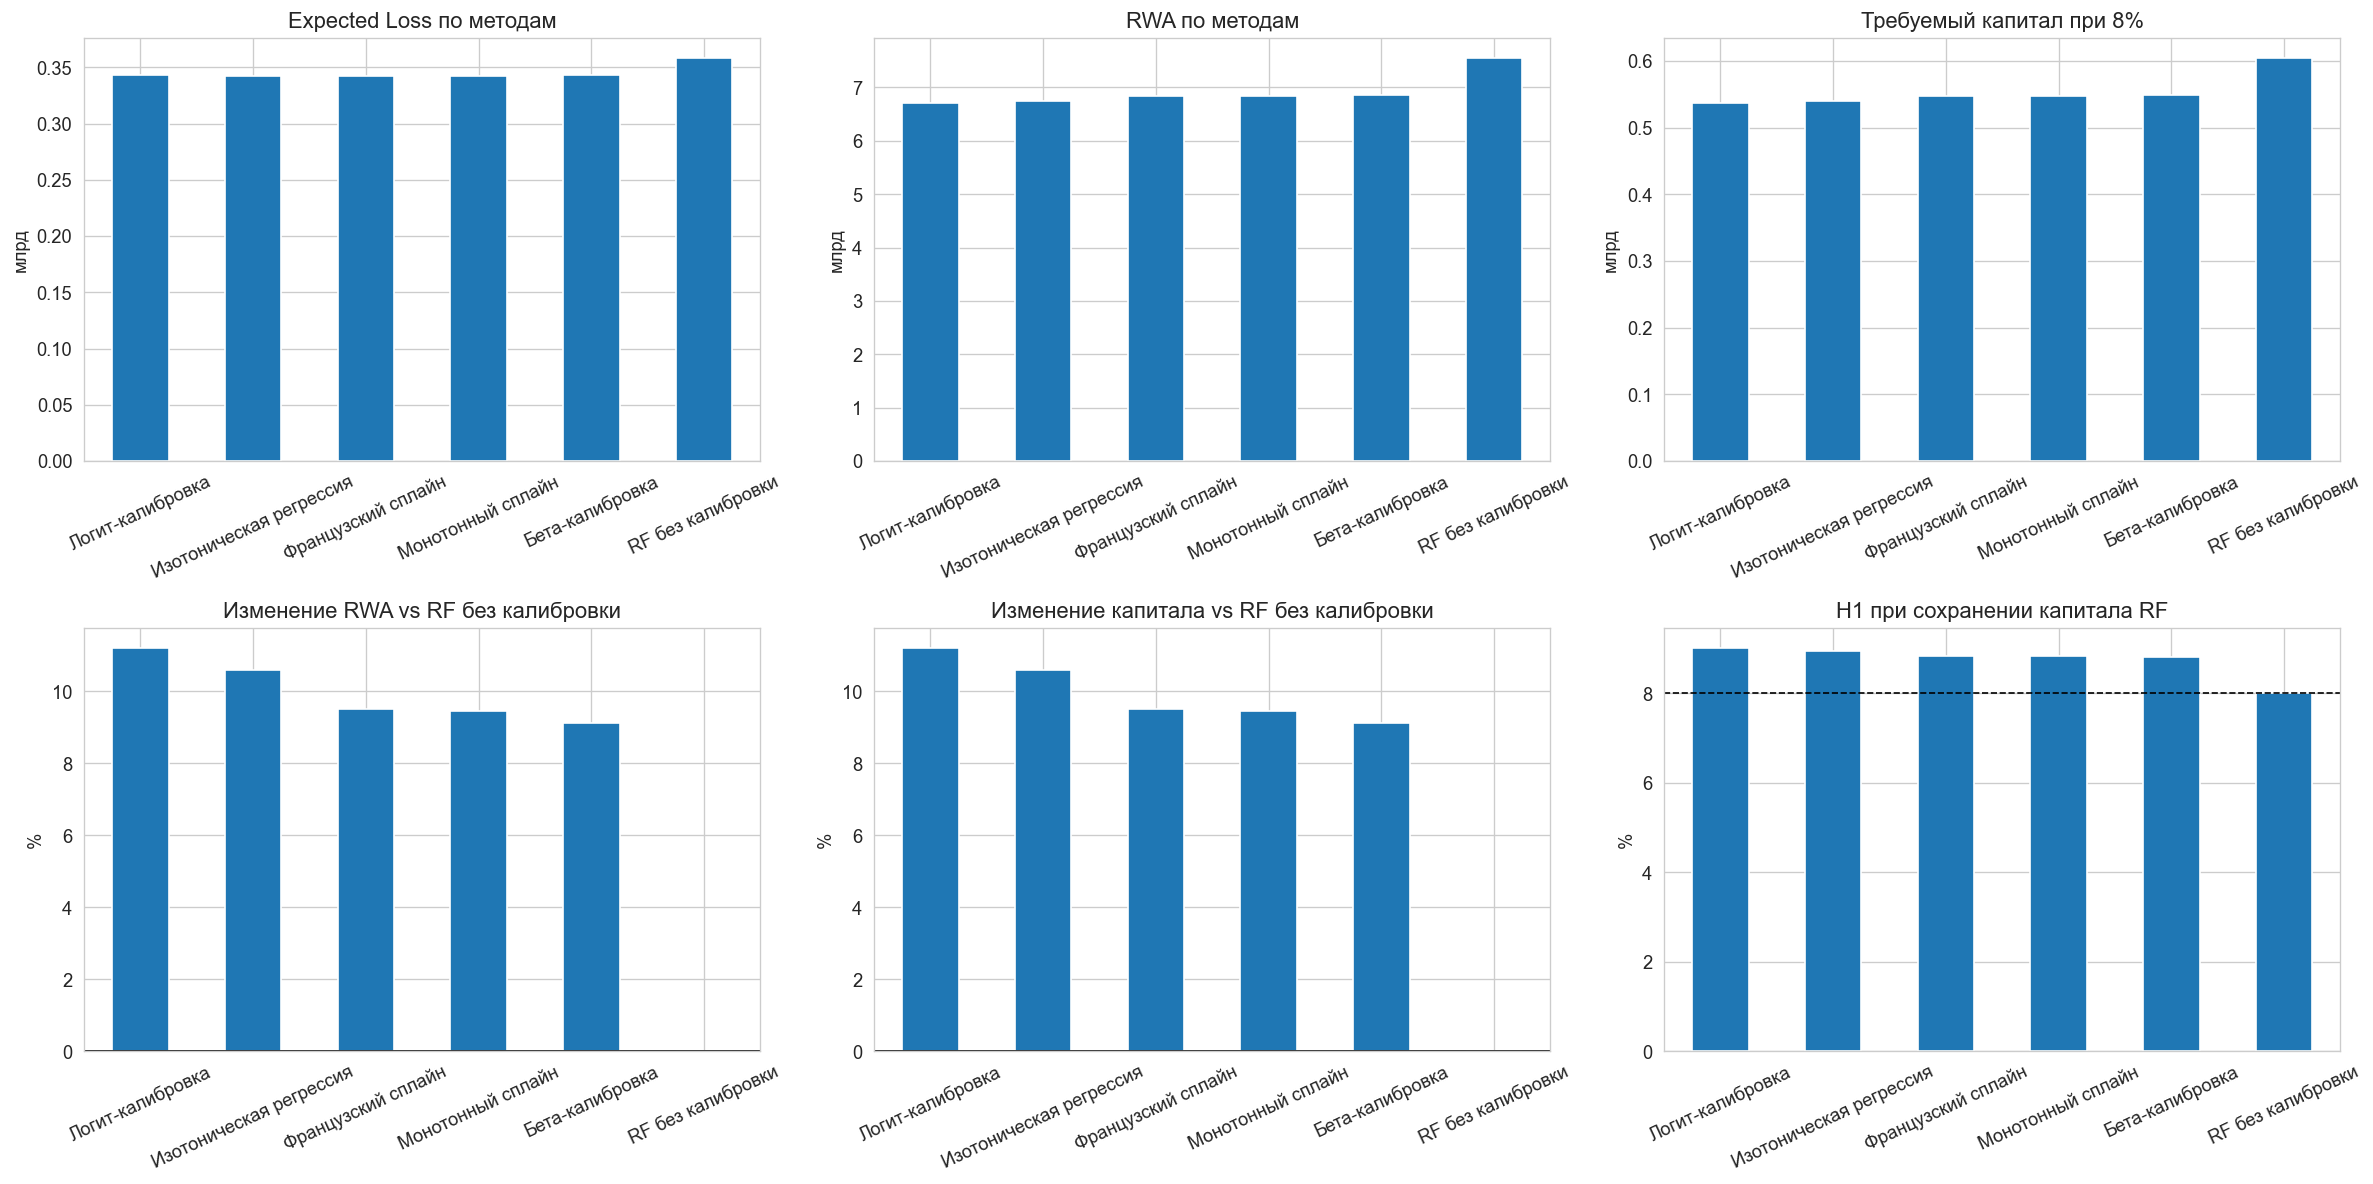

In [14]:
plot_df = df_rwa.reset_index().copy()
plot_df["EL, млрд"] = plot_df["total_expected_loss"] / 1_000_000_000
plot_df["RWA, млрд"] = plot_df["total_rwa"] / 1_000_000_000
plot_df["Капитал, млрд"] = plot_df["total_required_capital"] / 1_000_000_000
plot_df["Изм. RWA, %"] = 100 * plot_df["rwa_saving_vs_baseline_pct"]
plot_df["Изм. капитала, %"] = 100 * plot_df["capital_saving_vs_baseline_pct"]
plot_df["H1, %"] = 100 * plot_df["h1_if_keep_raw_capital"]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

plot_df.plot(x="method", y="EL, млрд", kind="bar", ax=axes[0, 0], legend=False, rot=25, title="Expected Loss по методам")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("млрд")

plot_df.plot(x="method", y="RWA, млрд", kind="bar", ax=axes[0, 1], legend=False, rot=25, title="RWA по методам")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("млрд")

plot_df.plot(x="method", y="Капитал, млрд", kind="bar", ax=axes[0, 2], legend=False, rot=25, title="Требуемый капитал при 8%")
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("млрд")

plot_df.plot(x="method", y="Изм. RWA, %", kind="bar", ax=axes[1, 0], legend=False, rot=25, title="Изменение RWA vs RF без калибровки")
axes[1, 0].axhline(0, color="black", lw=1)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("%")

plot_df.plot(x="method", y="Изм. капитала, %", kind="bar", ax=axes[1, 1], legend=False, rot=25, title="Изменение капитала vs RF без калибровки")
axes[1, 1].axhline(0, color="black", lw=1)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("%")

plot_df.plot(x="method", y="H1, %", kind="bar", ax=axes[1, 2], legend=False, rot=25, title="H1 при сохранении капитала RF")
axes[1, 2].axhline(100 * capital_assumptions.capital_ratio, color="black", lw=1, linestyle="--")
axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("%")

plt.tight_layout()
plt.show()

## 7. Оценка устойчивости результатов

При близких значениях метрик точечные оценки сами по себе могут вводить в заблуждение. Поэтому устойчивость результатов проверяется через **bootstrap confidence intervals** для Brier Score и AUC.

Если доверительные интервалы методов существенно перекрываются, это означает, что различия между ними малы и не дают оснований объявлять одного явного победителя только по одной точечной метрике.

In [15]:
from sklearn.metrics import roc_auc_score

boot_rows = []

print("Bootstrap 95% CI (1000 итераций) на OOT Test...")
print(f"{'Метод':<28} {'Brier':>7}  {'95% CI Brier':>18}  {'AUC':>7}  {'95% CI AUC':>18}")
print("-" * 85)

for name, probs in all_preds.items():
    ci_brier = bootstrap_ci(y_test.values, probs, brier_score,   n_iter=1000, random_state=42)
    ci_auc   = bootstrap_ci(y_test.values, probs, roc_auc_score, n_iter=1000, random_state=42)

    boot_rows.append({
        "method": name,
        "brier_point": ci_brier["point_estimate"],
        "brier_ci_lower": ci_brier["ci_lower"],
        "brier_ci_upper": ci_brier["ci_upper"],
        "auc_point": ci_auc["point_estimate"],
        "auc_ci_lower": ci_auc["ci_lower"],
        "auc_ci_upper": ci_auc["ci_upper"],
    })

    print(
        f"{name:<28} "
        f"{ci_brier['point_estimate']:>7.5f}  "
        f"[{ci_brier['ci_lower']:.5f}, {ci_brier['ci_upper']:.5f}]  "
        f"{ci_auc['point_estimate']:>7.4f}  "
        f"[{ci_auc['ci_lower']:.4f}, {ci_auc['ci_upper']:.4f}]"
    )

df_boot = pd.DataFrame(boot_rows).set_index("method")

print("\nИнтерпретация: если интервалы по Brier заметно перекрываются, различия между методами невелики.")


Bootstrap 95% CI (1000 итераций) на OOT Test...
Метод                          Brier        95% CI Brier      AUC          95% CI AUC
-------------------------------------------------------------------------------------


RF без калибровки            0.06134  [0.05753, 0.06528]   0.9316  [0.9220, 0.9412]


Логит-калибровка             0.06105  [0.05702, 0.06509]   0.9316  [0.9220, 0.9412]


Изотоническая регрессия      0.06094  [0.05678, 0.06511]   0.9313  [0.9216, 0.9408]


Бета-калибровка              0.06103  [0.05692, 0.06515]   0.9316  [0.9220, 0.9412]


Монотонный сплайн            0.06102  [0.05689, 0.06513]   0.9315  [0.9218, 0.9412]


Французский сплайн           0.06101  [0.05688, 0.06512]   0.9315  [0.9218, 0.9412]

Интерпретация: если интервалы по Brier заметно перекрываются, различия между методами невелики.


### Анализ по полной шкале вероятностей

Ниже калибровка и распределение PD показаны **на всей шкале [0; 1]**, а не только в той области, где сосредоточена основная масса наблюдений.  
Дополнительно для каждого метода строится таблица фиксированных биннов `[0.0–0.1], …, [0.9–1.0]`, чтобы увидеть, **как именно модель распределяет наблюдения и дефолты по всей шкале риска**.


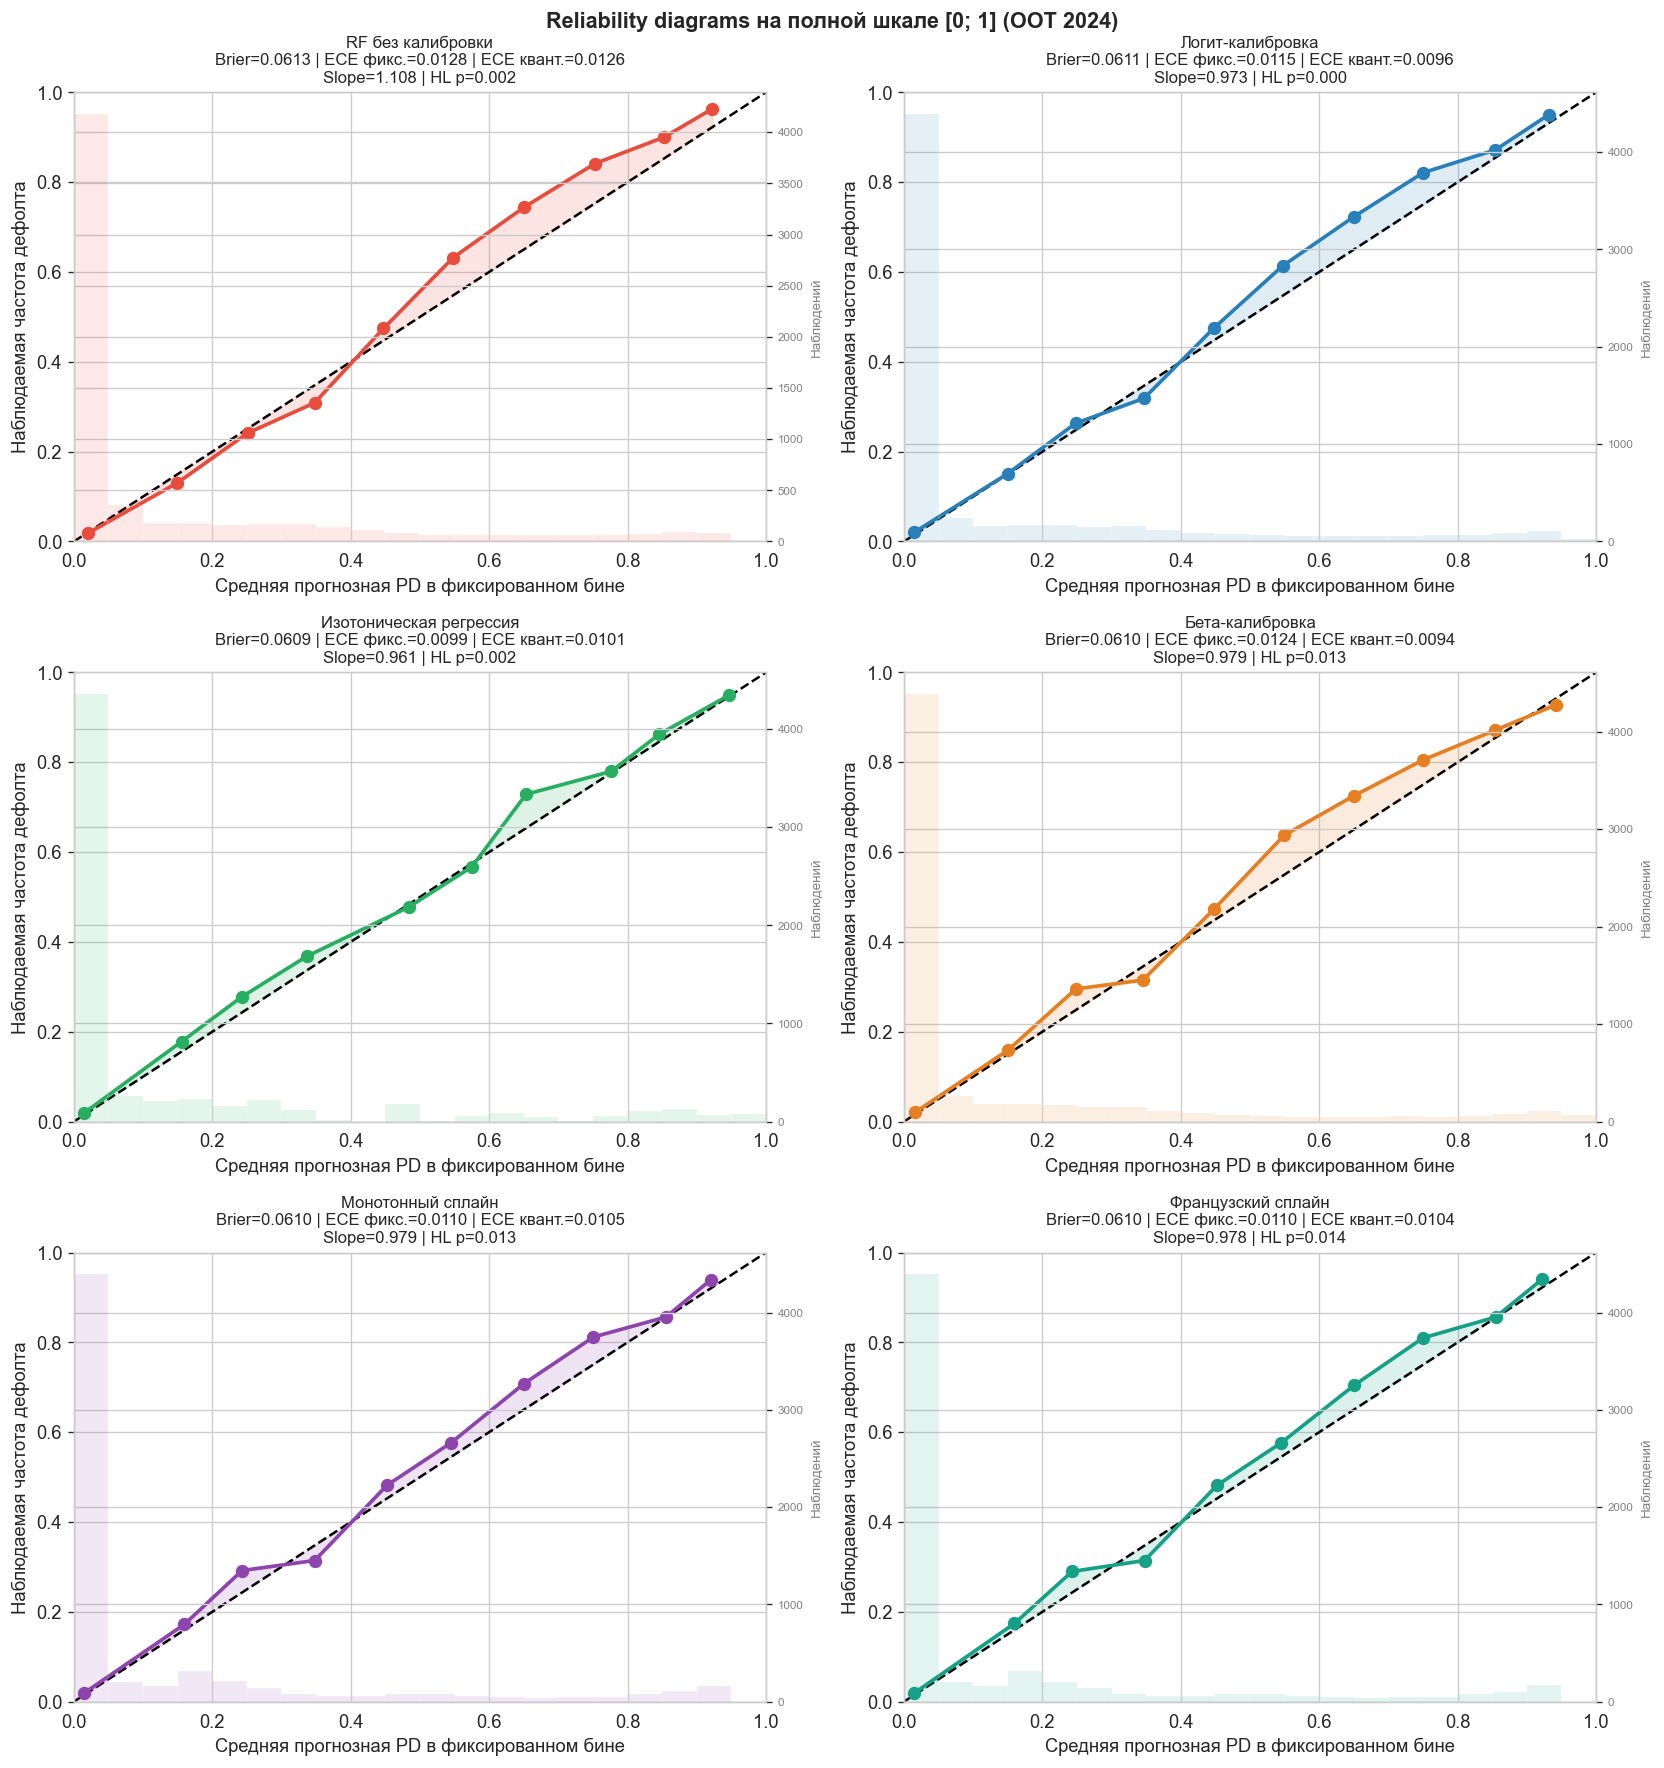

Распределение наблюдений и дефолтов по фиксированным бинам на полной шкале [0; 1]:

RF без калибровки
          bin    n  share  avg_pd  default_rate  defaults
(-0.001, 0.1] 4536  71.19  0.0201        0.0183        83
   (0.1, 0.2]  354   5.56  0.1490        0.1299        46
   (0.2, 0.3]  340   5.34  0.2510        0.2412        82
   (0.3, 0.4]  311   4.88  0.3478        0.3087        96
   (0.4, 0.5]  194   3.04  0.4473        0.4742        92
   (0.5, 0.6]  125   1.96  0.5480        0.6320        79
   (0.6, 0.7]  133   2.09  0.6506        0.7444        99
   (0.7, 0.8]  126   1.98  0.7526        0.8413       106
   (0.8, 0.9]  171   2.68  0.8533        0.9006       154
   (0.9, 1.0]   82   1.29  0.9224        0.9634        79

Логит-калибровка
          bin    n  share  avg_pd  default_rate  defaults
(-0.001, 0.1] 4637  72.77  0.0145        0.0201        93
   (0.1, 0.2]  324   5.08  0.1499        0.1512        49
   (0.2, 0.3]  323   5.07  0.2480        0.2632        85
   (0.3, 0

In [16]:
all_methods = {"RF без калибровки": scores_test, **calibrated_probs}

n_methods = len(all_methods)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, (name, probs) in enumerate(all_methods.items()):
    ax = axes[i]
    mean_pred, frac_pos = get_calibration_curve(y_test.values, probs, n_bins=10, strategy="uniform")
    m = summary_metrics(y_test.values, probs)

    ax.plot([0, 1], [0, 1], "k--", lw=1.5)
    ax.plot(mean_pred, frac_pos, "o-", color=COLORS[i], lw=2.2, ms=7)
    ax.fill_between(mean_pred, mean_pred, frac_pos, alpha=0.15, color=COLORS[i])

    ax2 = ax.twinx()
    ax2.hist(probs, bins=np.linspace(0, 1, 21), alpha=0.12, color=COLORS[i])
    ax2.set_ylabel("Наблюдений", fontsize=8, color="gray")
    ax2.tick_params(axis="y", labelsize=7, labelcolor="gray")

    subtitle = (
        f'Brier={m["brier_score"]:.4f} | ECE фикс.={m["ece_uniform"]:.4f} | ECE квант.={m["ece_quantile"]:.4f}\n'
        f'Slope={m["cal_slope"]:.3f} | HL p={m["hl_p_value"]:.3f}'
    )
    ax.set_title(f"{name}\n{subtitle}", fontsize=10)
    ax.set_xlabel("Средняя прогнозная PD в фиксированном бине")
    ax.set_ylabel("Наблюдаемая частота дефолта")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Reliability diagrams на полной шкале [0; 1] (OOT 2024)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Распределение наблюдений и дефолтов по фиксированным бинам на полной шкале [0; 1]:")
for name, probs in all_methods.items():
    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)
    bin_table = fixed_bin_table(y_test.values, probs, n_bins=10).copy()
    bin_table["share"] = (100 * bin_table["share"]).round(2)
    bin_table["avg_pd"] = bin_table["avg_pd"].round(4)
    bin_table["default_rate"] = bin_table["default_rate"].round(4)
    print(bin_table.to_string(index=False))

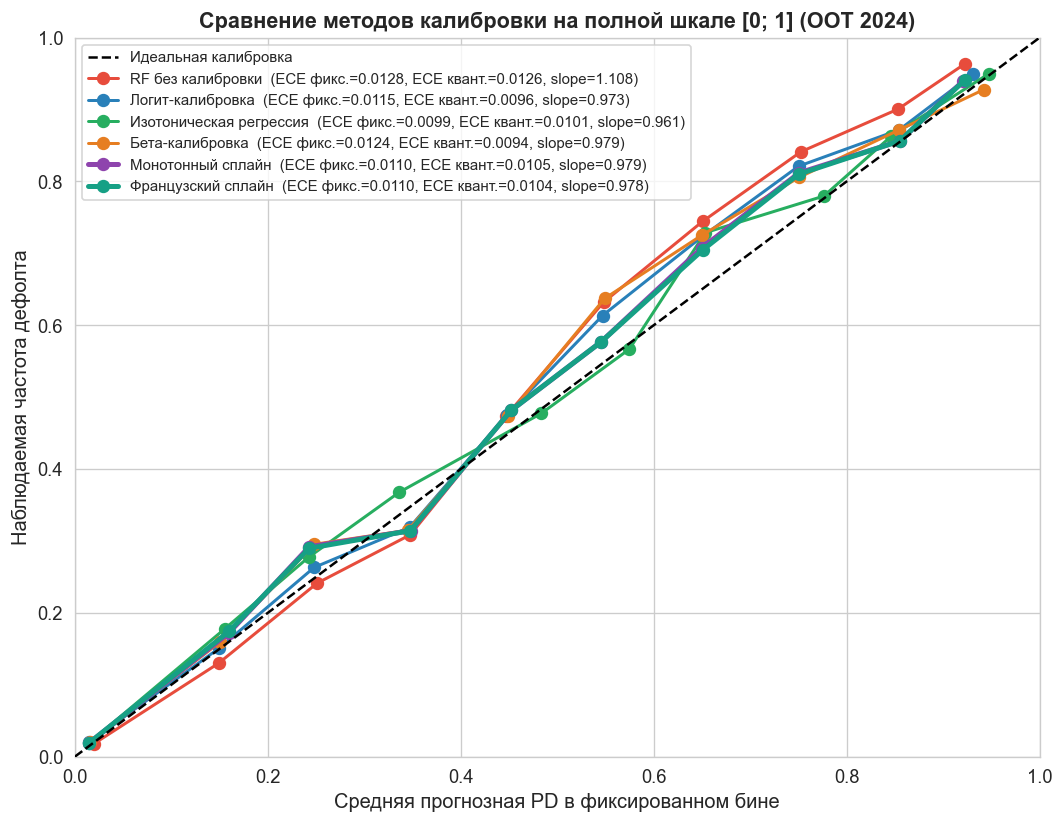

In [17]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Идеальная калибровка", zorder=5)

for (name, probs), color in zip(all_methods.items(), COLORS):
    mean_pred, frac_pos = get_calibration_curve(y_test.values, probs, n_bins=10, strategy="uniform")
    m = summary_metrics(y_test.values, probs)
    lw = 3.0 if "сплайн" in name.lower() else 1.8
    label = f"{name}  (ECE фикс.={m['ece_uniform']:.4f}, ECE квант.={m['ece_quantile']:.4f}, slope={m['cal_slope']:.3f})"
    ax.plot(mean_pred, frac_pos, "o-", color=color, lw=lw, ms=7, label=label)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Средняя прогнозная PD в фиксированном бине", fontsize=12)
ax.set_ylabel("Наблюдаемая частота дефолта", fontsize=12)
ax.set_title("Сравнение методов калибровки на полной шкале [0; 1] (OOT 2024)", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 8. Выводы, практическая интерпретация и ограничения

In [18]:
print("=" * 78)
print("ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ КАЛИБРОВКИ PD")
print("=" * 78)
display_cols = ["brier_score", "log_loss", "ece_uniform", "ece_quantile", "hl_p_value", "cal_slope", "cal_intercept"]
print(df_results[display_cols].sort_values(["brier_score", "ece_quantile"]).to_string())

best_brier = df_results["brier_score"].idxmin()
best_ece = df_results["ece_quantile"].idxmin()
best_rwa = df_rwa["total_rwa"].idxmin()
best_required_capital = df_rwa["total_required_capital"].idxmin()
best_h1 = df_rwa["h1_if_keep_raw_capital"].idxmax()

print("\n" + "=" * 78)
print("КЛЮЧЕВЫЕ ВЫВОДЫ")
print("=" * 78)
print("1. Портфель специально содержит как низкорисковые, так и высокорисковые сегменты,")
print("   поэтому графики калибровки можно анализировать на полной шкале [0; 1].")
print(f"   Максимальная PD у RF без калибровки на OOT: {scores_test.max():.3f}.")
print(f"2. Лучший Brier Score показывает: {best_brier} ({df_results.loc[best_brier, 'brier_score']:.5f}).")
print(f"   Минимальный ECE на квантильных бинах показывает: {best_ece} ({df_results.loc[best_ece, 'ece_quantile']:.5f}).")
print("3. Французский сплайн — исследовательская двухшаговая схема: логит-калибровка + монотонный сплайн.")
print("4. Статистическое качество калибровки и эффект на капитал специально разделены: лучший метод по Brier")
print("   не обязан одновременно давать минимальный RWA.")

print("\n" + "=" * 78)
print("ЭФФЕКТ НА RWA И ТРЕБУЕМЫЙ КАПИТАЛ")
print("=" * 78)
print(f"1. Минимальный RWA даёт: {best_rwa} — {df_rwa.loc[best_rwa, 'total_rwa']:,.0f}.")
print(f"2. Минимальный требуемый капитал даёт: {best_required_capital} — {df_rwa.loc[best_required_capital, 'total_required_capital']:,.0f}.")
print(f"   Изменение капитала относительно RF без калибровки: "
      f"{df_rwa.loc[best_required_capital, 'capital_saving_vs_baseline']:,.0f} "
      f"({df_rwa.loc[best_required_capital, 'capital_saving_vs_baseline_pct']:.2%}).")
print("3. Capital impact по каждому методу:")
for method in df_rwa.index:
    if method == "RF без калибровки":
        continue
    print(f"   - {method}: изменение RWA = {df_rwa.loc[method, 'rwa_saving_vs_baseline']:,.0f} "
          f"({df_rwa.loc[method, 'rwa_saving_vs_baseline_pct']:.2%}), "
          f"изменение капитала = {df_rwa.loc[method, 'capital_saving_vs_baseline']:,.0f} "
          f"({df_rwa.loc[method, 'capital_saving_vs_baseline_pct']:.2%}).")
print(f"4. Если сохранить капитал RF без калибровки, максимальный H1 даёт: {best_h1} — "
      f"{df_rwa.loc[best_h1, 'h1_if_keep_raw_capital']:.2%}.")

print("\n" + "=" * 78)
print("ОГРАНИЧЕНИЯ")
print("=" * 78)
print("- Портфель синтетический; абсолютные величины капитала нельзя напрямую переносить на реальный банк.")
print("- Basel-style расчет упрощен и нужен для анализа чувствительности капитала к PD, а не для регуляторной отчетности.")
print("- Выбор метода калибровки должен учитывать метрики, устойчивость, интерпретируемость и governance.")

ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ КАЛИБРОВКИ PD
                         brier_score  log_loss  ece_uniform  ece_quantile  hl_p_value  cal_slope  cal_intercept
method                                                                                                         
Изотоническая регрессия      0.06094   0.20955      0.00994       0.01015      0.0019     0.9610         0.1188
Французский сплайн           0.06101   0.20862      0.01097       0.01043      0.0139     0.9778         0.1372
Монотонный сплайн            0.06102   0.20865      0.01104       0.01049      0.0133     0.9791         0.1395
Бета-калибровка              0.06103   0.20837      0.01236       0.00938      0.0130     0.9785         0.1309
Логит-калибровка             0.06105   0.20884      0.01152       0.00963      0.0003     0.9733         0.1247
RF без калибровки            0.06134   0.20908      0.01279       0.01258      0.0024     1.1082         0.1525

КЛЮЧЕВЫЕ ВЫВОДЫ
1. Портфель специально содержит как низкориско